(2930, 80)
str        43
int64      26
float64    11
Name: count, dtype: int64
PoolQC          2917
MiscFeature     2824
Alley           2732
Fence           2358
MasVnrType      1775
FireplaceQu     1422
LotFrontage      490
GarageQual       159
GarageCond       159
GarageYrBlt      159
GarageFinish     159
GarageType       157
BsmtExposure      83
BsmtFinType2      81
BsmtCond          80
BsmtQual          80
BsmtFinType1      80
MasVnrArea        23
BsmtFullBath       2
BsmtHalfBath       2
BsmtFinSF1         1
BsmtFinSF2         1
Electrical         1
TotalBsmtSF        1
BsmtUnfSF          1
GarageArea         1
GarageCars         1
dtype: int64


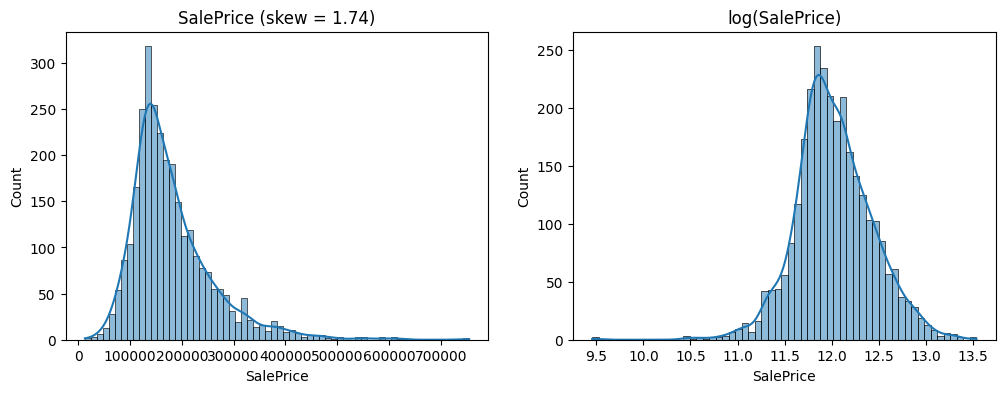

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('AmesHousing.csv')

print(df.shape)
print(df.dtypes.value_counts())

# пропуски
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print(na)

# цільова змінна
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=ax[0])
ax[0].set_title(f"SalePrice (skew = {df['SalePrice'].skew():.2f})")
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=ax[1])
ax[1].set_title('log(SalePrice)')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

y = np.log1p(df['SalePrice'])
X = df.drop(columns=['SalePrice'])

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

print(X_tr.shape, X_val.shape, X_te.shape)  # 60% / 20% / 20%

(1758, 79) (586, 79) (586, 79)


OverallQual     0.813623
GrLivArea       0.689894
GarageCars      0.666580
GarageArea      0.636707
TotalBsmtSF     0.631437
1stFlrSF        0.600993
YearBuilt       0.593245
FullBath        0.572085
YearRemodAdd    0.559378
GarageYrBlt     0.558601
TotRmsAbvGrd    0.484634
Fireplaces      0.480506
MasVnrArea      0.443722
BsmtFinSF1      0.409627
LotFrontage     0.349152
WoodDeckSF      0.343457
HalfBath        0.311911
BsmtFullBath    0.293405
OpenPorchSF     0.276021
2ndFlrSF        0.271378
Name: SalePrice, dtype: float64


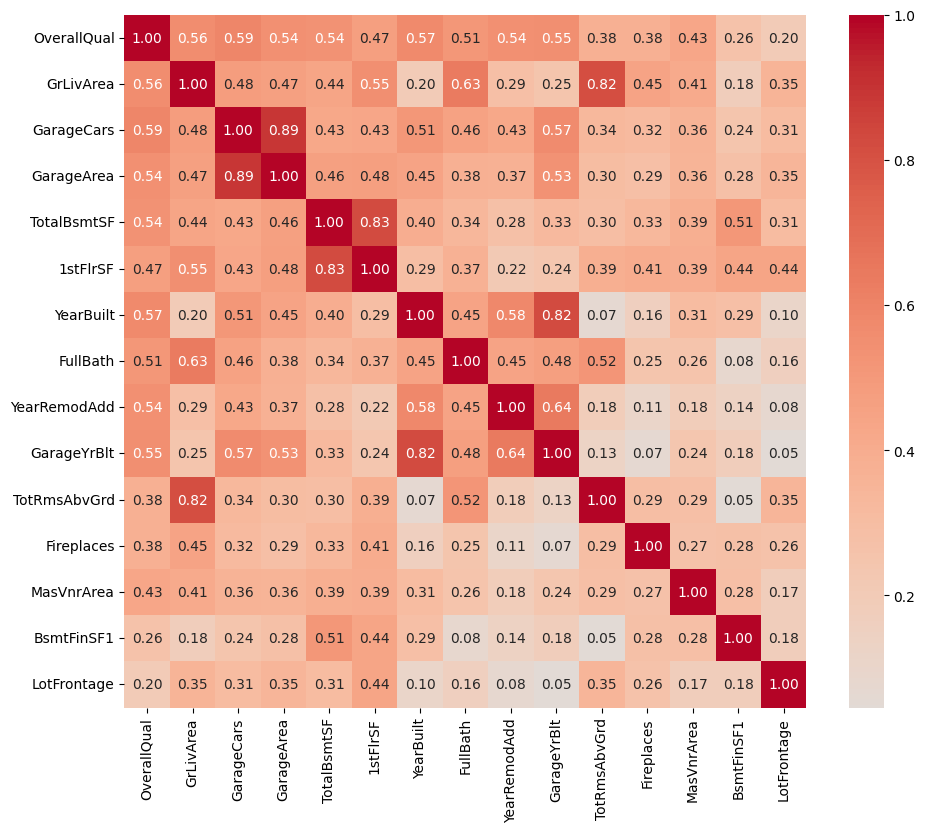

In [5]:
num_cols = X_tr.select_dtypes(include=[np.number]).columns
corr = X_tr[num_cols].join(y_tr).corr()['SalePrice'].drop('SalePrice')
print(corr.abs().sort_values(ascending=False).head(20))

# кореляції МІЖ ознаками — шукаємо мультиколінеарність
top = corr.abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(11, 9))
sns.heatmap(X_tr[top].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

In [8]:
NUM = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'GarageArea', 'YearBuilt', 'YearRemodAdd', 'FullBath', 'TotRmsAbvGrd','Fireplaces', 'LotArea', 'MasVnrArea']
ORD = ['KitchenQual', 'ExterQual', 'BsmtQual']   # порядкові
CAT = ['Neighborhood', 'BldgType', 'HouseStyle'] # номінальні

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

QUAL = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

def prepare(X, fit=False, state={}):
    Xn = X[NUM].copy()
    if fit:
        state['medians'] = Xn.median()          # медіани ТІЛЬКИ з train
    Xn = Xn.fillna(state['medians'])

    Xo = X[ORD].apply(lambda s: s.map(QUAL)).fillna(0)  # NaN = об'єкта немає

    if fit:
        state['ohe'] = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
        state['ohe'].fit(X[CAT].fillna('NA'))
    Xc = state['ohe'].transform(X[CAT].fillna('NA'))

    out = np.hstack([Xn.values, Xo.values, Xc])

    if fit:
        state['scaler'] = StandardScaler().fit(out)   # μ, σ ТІЛЬКИ з train
    return state['scaler'].transform(out), state

state = {}
Xtr, state = prepare(X_tr, fit=True, state=state)
Xval, _ = prepare(X_val, state=state)
Xte,  _ = prepare(X_te,  state=state)

ytr, yval, yte = y_tr.values, y_val.values, y_te.values
print(Xtr.shape, Xval.shape, Xte.shape)

(1758, 53) (586, 53) (586, 53)


In [10]:
import numpy as np


class LinearRegressionNP:
    """
    Лінійна регресія: y_hat = X @ w + b
    Усі обчислення векторизовані, циклів for немає.
    l2 — параметр Ridge-регуляризації (знадобиться на Етапі 6, за замовчуванням вимкнено).
    """

    def __init__(self, n_features, l2=0.0, seed=42):
        rng = np.random.default_rng(seed)
        # мала випадкова ініціалізація; нулі теж працюють, але так видно збіжність
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.l2 = l2

    # --- прогноз -------------------------------------------------------
    def predict(self, X):
        return X @ self.w + self.b

    # --- функція втрат -------------------------------------------------
    def cost(self, X, y):
        m = X.shape[0]
        err = self.predict(X) - y
        mse = (err @ err) / m                      # еквівалент np.mean(err**2)
        reg = self.l2 * (self.w @ self.w) / (2 * m)
        return mse + reg

    # --- градієнти -----------------------------------------------------
    def gradients(self, X, y):
        m = X.shape[0]
        err = self.predict(X) - y                  # (m,)
        dw = (2 / m) * (X.T @ err) + (self.l2 / m) * self.w
        db = (2 / m) * err.sum()
        return dw, db

    # --- крок оновлення ------------------------------------------------
    def step(self, dw, db, lr):
        self.w -= lr * dw
        self.b -= lr * db

In [11]:
def grad_check(X, y, eps=1e-6):
    model = LinearRegressionNP(X.shape[1])
    dw, db = model.gradients(X, y)

    # чисельна похідна по кількох випадкових координатах w
    idx = np.random.default_rng(0).choice(X.shape[1], size=5, replace=False)
    num = []
    for j in idx:                      # цикл ЛИШЕ для перевірки, не для навчання
        orig = model.w[j]
        model.w[j] = orig + eps; plus = model.cost(X, y)
        model.w[j] = orig - eps; minus = model.cost(X, y)
        model.w[j] = orig
        num.append((plus - minus) / (2 * eps))

    print('аналітичні:', np.round(dw[idx], 6))
    print('чисельні:  ', np.round(num, 6))
    print('макс. різниця:', np.max(np.abs(dw[idx] - num)))

grad_check(Xtr[:200], ytr[:200])

аналітичні: [-2.206061  0.572863  0.349721  1.296962  0.290291]
чисельні:   [-2.206061  0.572863  0.349721  1.296962  0.29029 ]
макс. різниця: 1.3880201044091933e-08


In [12]:
def train(X, y, batch_size=None, lr=0.01, epochs=200, l2=0.0, tol=1e-7, patience=5, seed=42, X_val=None, y_val=None):
    """
    batch_size = None -> Batch GD (увесь датасет)
    batch_size = 1    -> SGD
    batch_size = B    -> Mini-batch GD

    Критерій зупинки: |J_prev - J| < tol протягом patience епох поспіль.
    """
    m, n = X.shape
    model = LinearRegressionNP(n, l2=l2, seed=seed)
    rng = np.random.default_rng(seed)
    bs = m if batch_size is None else batch_size

    history, val_history = [], []
    stale = 0

    for ep in range(epochs):
        idx = rng.permutation(m)            # перемішування кожної епохи

        # проходимо датасет батчами
        for start in range(0, m, bs):
            part = idx[start:start + bs]
            dw, db = model.gradients(X[part], y[part])
            model.step(dw, db, lr)

        J = model.cost(X, y)                # повна вартість у кінці епохи
        history.append(J)
        if X_val is not None:
            val_history.append(model.cost(X_val, y_val))

        if not np.isfinite(J):              # розбіжність — знадобиться в Експерименті Б
            print(f'  розбіжність на епосі {ep}')
            break

        if ep > 0 and abs(history[-2] - J) < tol:
            stale += 1
            if stale >= patience:
                print(f'  зупинка на епосі {ep} (J = {J:.6f})')
                break
        else:
            stale = 0

    return model, np.array(history), np.array(val_history)

In [13]:
for lr in [0.5, 0.1, 0.05, 0.01, 0.001]:
    _, h, _ = train(Xtr, ytr, batch_size=None, lr=lr, epochs=100)
    print(f'Batch,      lr={lr:<6} -> J = {h[-1]:.5f}')

for lr in [0.05, 0.01, 0.005, 0.001, 0.0005]:
    _, h, _ = train(Xtr, ytr, batch_size=1, lr=lr, epochs=20)
    print(f'SGD,        lr={lr:<6} -> J = {h[-1]:.5f}')

for lr in [0.1, 0.05, 0.01, 0.005, 0.001]:
    _, h, _ = train(Xtr, ytr, batch_size=32, lr=lr, epochs=50)
    print(f'Mini-batch, lr={lr:<6} -> J = {h[-1]:.5f}')

Batch,      lr=0.5    -> J = 740926183270264579557388590765842122250870162625355607131361257155311129028345458882319831453018664195919439149909165677877584086407094464808729109110074688667648.00000
Batch,      lr=0.1    -> J = 0.02092
Batch,      lr=0.05   -> J = 0.02104
Batch,      lr=0.01   -> J = 2.56125
Batch,      lr=0.001  -> J = 96.76235
  розбіжність на епосі 1
SGD,        lr=0.05   -> J = nan


C:\Users\uzimi\AppData\Local\Temp\ipykernel_10340\767909073.py:26: RuntimeWarning: overflow encountered in matmul
  mse = (err @ err) / m                      # еквівалент np.mean(err**2)
C:\Users\uzimi\AppData\Local\Temp\ipykernel_10340\767909073.py:27: RuntimeWarning: overflow encountered in matmul
  reg = self.l2 * (self.w @ self.w) / (2 * m)
C:\Users\uzimi\AppData\Local\Temp\ipykernel_10340\767909073.py:27: RuntimeWarning: invalid value encountered in scalar multiply
  reg = self.l2 * (self.w @ self.w) / (2 * m)


SGD,        lr=0.01   -> J = 1872367266387899498555992458861523859935602344862315208507886569793508673602856368416851233143787135658488135563569392673374333587595786721665605593533415079284657618816294971429093376.00000
SGD,        lr=0.005  -> J = 186647947784359505898611491903177814098245367436843699021947622268259237215475901399040.00000
SGD,        lr=0.001  -> J = 1279632023099824.00000
SGD,        lr=0.0005 -> J = 0.02113
Mini-batch, lr=0.1    -> J = 216777227787288838556407778416124930601733523656474956454122593653575092510486190399833596841439245937275832158186045015905533952.00000
Mini-batch, lr=0.05   -> J = 29554115809986157487759587312733209827944492822615861722517340160.00000
Mini-batch, lr=0.01   -> J = 0.02098
Mini-batch, lr=0.005  -> J = 0.02092
Mini-batch, lr=0.001  -> J = 0.02364


In [16]:
for lr in [0.0005, 0.0002, 0.0001]:
    _, h, _ = train(Xtr, ytr, batch_size=1, lr=lr, epochs=30)
    print(f'SGD, lr={lr:<7} -> J = {h[-1]:.5f}')

SGD, lr=0.0005  -> J = 0.02105
SGD, lr=0.0002  -> J = 0.02094
SGD, lr=0.0001  -> J = 0.02103


  зупинка на епосі 168 (J = 0.020901)


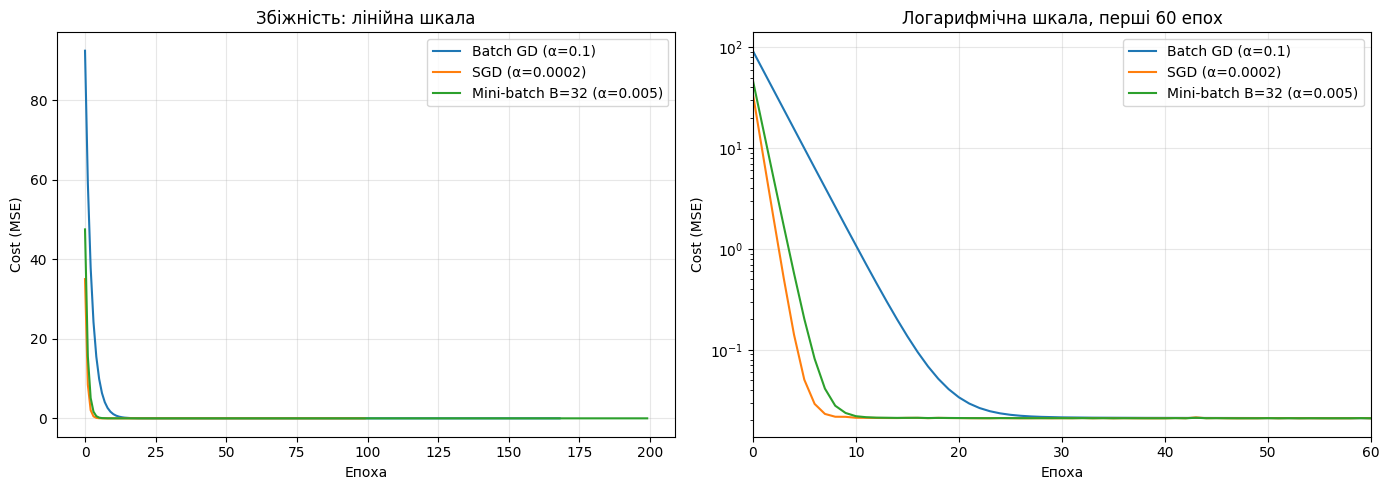

In [17]:
LR_BATCH, LR_SGD, LR_MINI = 0.1, 0.0002, 0.005

m_batch, h_batch, v_batch = train(Xtr, ytr, None, LR_BATCH, 500, X_val=Xval, y_val=yval)
m_sgd,   h_sgd,   v_sgd   = train(Xtr, ytr, 1,    LR_SGD,   100, X_val=Xval, y_val=yval)
m_mini,  h_mini,  v_mini  = train(Xtr, ytr, 32,   LR_MINI,  200, X_val=Xval, y_val=yval)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for h, name in [(h_batch, f'Batch GD (α={LR_BATCH})'),
                (h_sgd,   f'SGD (α={LR_SGD})'),
                (h_mini,  f'Mini-batch B=32 (α={LR_MINI})')]:
    ax[0].plot(h, label=name)
    ax[1].plot(h, label=name)

ax[0].set(xlabel='Епоха', ylabel='Cost (MSE)', title='Збіжність: лінійна шкала')
ax[1].set(xlabel='Епоха', ylabel='Cost (MSE)', yscale='log', xlim=(0, 60), title='Логарифмічна шкала, перші 60 епох')
for a in ax:
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

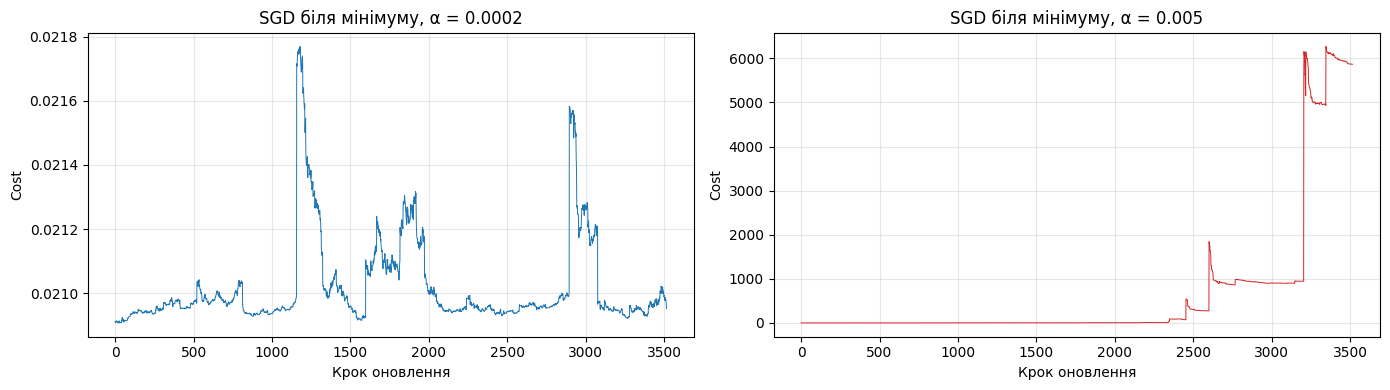

AttributeError: 'numpy.ndarray' object has no attribute 'ptp'

In [ ]:
import copy

def sgd_trace(model, lr, epochs, seed=0):
    model = copy.deepcopy(model)
    rng = np.random.default_rng(seed)
    trace = []
    for ep in range(epochs):
        for i in rng.permutation(len(Xtr)):
            dw, db = model.gradients(Xtr[i:i+1], ytr[i:i+1])
            model.step(dw, db, lr)
            trace.append(model.cost(Xtr, ytr))
    return np.array(trace)

# m_sgd уже навчена — стартуємо з околу мінімуму
t_small = sgd_trace(m_sgd, lr=0.0002, epochs=2)
t_big   = sgd_trace(m_sgd, lr=0.005,  epochs=2)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(t_small, lw=0.7)
ax[0].set_title('SGD біля мінімуму, α = 0.0002')
ax[1].plot(t_big, lw=0.7, color='tab:red')
ax[1].set_title('SGD біля мінімуму, α = 0.005')
for a in ax:
    a.set(xlabel='Крок оновлення', ylabel='Cost'); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'α=0.0002: середнє {t_small.mean():.5f}, розмах {np.ptp(t_small):.5f}')
print(f'α=0.005:  середнє {t_big.mean():.2f},  розмах {np.ptp(t_big):.2f}')